# Multiple Regression after selection

#### Data Import

In [1]:
import intake
import numpy as np
import matplotlib.pylab as plt
import xarray as xr
import matplotlib.colors as colors
from shapely.geometry import Polygon, Point, box
from shapely import contains_xy
import time
from scipy.stats import linregress
import pandas as pd
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor


In [2]:
#import data (generated in this notebook)
edso1_clt_ac = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_dn23_clt_ac.nc")
edso1_clt_c = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_dn23_clt_c.nc")

In [3]:
#import combo data fro combined AC/C eddies with r > q75 and e < 20%
edso1_dn23_clt_q75_e20 = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_clt_q75_e20.nc")
edso1_dn23_hfls_q75_e20 = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_dn23_hfls_q75_e20.nc")
edso1_dn23_hfss_q75_e20 = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_dn23_hfss_q75_e20.nc")
edso1_dn23_sfcwind_q75_e20 = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_dn23_sfcwind_q75_e20.nc")

In [4]:
eerie_cat=intake.open_catalog("https://raw.githubusercontent.com/eerie-project/intake_catalogues/main/eerie.yaml")
da_atmos = eerie_cat["dkrz"]["disk"]["model-output"]["icon-esm-er"]["hist-1950"]["v20240618"]["atmos"]["gr025"]["2d_daily_mean"].to_dask()
da_ocean = eerie_cat["dkrz"]["disk"]["model-output"]["icon-esm-er"]["hist-1950"]["v20240618"]["ocean"]["gr025"]["2d_daily_mean"].to_dask()

In [5]:
#select atmos and ocean data for SO
da_atmos_so = da_atmos.where(da_atmos.lat < -50, drop = True)
da_ocean_so = da_ocean.where(da_ocean.lat < -50, drop = True)

In [6]:
edso1_clt = xr.concat([edso1_clt_ac, edso1_clt_c], dim="obs")
edso1_clt = edso1_clt.assign_coords(number=("obs", np.arange(edso1_clt.sizes["obs"])))

In [7]:
edso1_dn23_clt_q75_e20.amplitude

<xarray.DataArray 'amplitude' (obs: 60786)>
[60786 values with dtype=float64]
Coordinates:
  * obs       (obs) float64 422.0 426.0 474.0 ... 1.945e+06 1.946e+06 1.946e+06
    quantile  float64 ...
    number    (obs) int64 ...
Attributes:
    comment:    Magnitude of the height difference between the extremum of SS...
    long_name:  Amplitude
    units:      m
    min:        0.008
    max:        1.118

#### DOF Method

#### multiple regression OLS

In [22]:
#Convert xarray → pandas
ds_single = edso1_dn23_hfls_q75_e20.isel(NbSample=0)
df_pd = ds_single.to_dataframe().reset_index()

df_pd["amplitude"] = df_pd["amplitude"].abs()

#Standardize predictors
scaler = StandardScaler()
X = df_pd[["amplitude", "effective_radius", "effective_contour_shape_error"]]
X_std = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

X_std = X_std.rename(columns={
    "effective_contour_shape_error": "shape error",
    "amplitude": "amplitude",
    "effective_radius": "radius",
    "speed_average": "average speed"
})


# 3. Standardize y
y = df_pd["dif_hfls"].to_numpy().reshape(-1, 1)
y_std = StandardScaler().fit_transform(y).ravel()

# 4. Add constant
X_std = sm.add_constant(X_std)

# 5. Fit OLS
ols = sm.OLS(y_std, X_std).fit()

print(ols.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     120.7
Date:                Mon, 26 Jan 2026   Prob (F-statistic):           6.34e-78
Time:                        08:30:29   Log-Likelihood:                -86071.
No. Observations:               60786   AIC:                         1.722e+05
Df Residuals:                   60782   BIC:                         1.722e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const       -7.066e-16      0.004  -1.75e-13      

In [16]:
#function for calculating adjusted statistics for effective sample size
import numpy as np
from scipy import stats

def adjust_inference_multivariate(model, n_eff, alpha=0.05):
    """
    Adjust t-values, p-values, and confidence intervals for an OLS model
    using an effective sample size n_eff.

    Parameters
    ----------
    model : statsmodels OLS results
        Fitted OLS model.
    n_eff : float
        Effective sample size.
    alpha : float
        Confidence level for CI.

    Returns
    -------
    dict
        Dictionary with adjusted SE, t, p, CI for all coefficients.
    """

    params = model.params
    se_orig = model.bse
    n = model.nobs
    k = len(params)  # number of coefficients including constant

    # Adjusted standard errors
    se_adj = se_orig * np.sqrt(n / n_eff)

    # Adjusted t-values
    t_adj = params / se_adj

    # Effective degrees of freedom
    df_eff = n_eff - k

    # Adjusted p-values
    p_adj = 2 * (1 - stats.t.cdf(np.abs(t_adj), df=df_eff))

    # Adjusted confidence intervals
    tcrit = stats.t.ppf(1 - alpha/2, df=df_eff)
    ci_low = params - tcrit * se_adj
    ci_high = params + tcrit * se_adj

    return {
        "beta": params,
        "se_adjusted": se_adj,
        "t_adjusted": t_adj,
        "p_adjusted": p_adj,
        "ci_adjusted": np.column_stack([ci_low, ci_high]),
        "df_eff": df_eff
    }


In [17]:
n = len(df_pd)
n_eff = n / 7  

adj_clt = adjust_inference_multivariate(ols, n_eff)
X_std_clt = X_std
print("beta", adj_clt["beta"])
print("se", adj_clt["se_adjusted"])
print("t", adj_clt["t_adjusted"])
print("p", adj_clt["p_adjusted"])
print("ci", adj_clt["ci_adjusted"])


beta const          1.821460e-17
amplitude      4.999091e-03
radius         1.173237e-02
shape error    4.728994e-03
dtype: float64
se const          0.010730
amplitude      0.012140
radius         0.012132
shape error    0.010778
dtype: float64
t const          1.697502e-15
amplitude      4.117838e-01
radius         9.670663e-01
shape error    4.387488e-01
dtype: float64
p [1.         0.68050807 0.33353782 0.66085445]
ci [[-0.0210338   0.0210338 ]
 [-0.01879836  0.02879654]
 [-0.01204907  0.0355138 ]
 [-0.01639915  0.02585714]]


In [19]:
adj_sfcwind = adjust_inference_multivariate(ols, n_eff)
X_std_sfcwind = X_std
print("beta", adj_sfcwind["beta"])
print("se", adj_sfcwind["se_adjusted"])
print("t", adj_sfcwind["t_adjusted"])
print("p", adj_sfcwind["p_adjusted"])
print("ci", adj_sfcwind["ci_adjusted"])


beta const         -1.235990e-17
amplitude      2.668625e-02
radius        -6.307405e-03
shape error    6.970837e-04
dtype: float64
se const          0.010728
amplitude      0.012138
radius         0.012130
shape error    0.010776
dtype: float64
t const         -1.152080e-15
amplitude      2.198581e+00
radius        -5.199937e-01
shape error    6.468580e-02
dtype: float64
p [1.         0.02793399 0.60308121 0.94842566]
ci [[-0.02103009  0.02103009]
 [ 0.00289301  0.0504795 ]
 [-0.03008464  0.01746983]
 [-0.02042733  0.0218215 ]]


In [21]:
adj_hfss = adjust_inference_multivariate(ols, n_eff)
X_std_hfss = X_std
print("beta", adj_hfss["beta"])
print("se", adj_hfss["se_adjusted"])
print("t", adj_hfss["t_adjusted"])
print("p", adj_hfss["p_adjusted"])
print("ci", adj_hfss["ci_adjusted"])


beta const         -9.042246e-16
amplitude     -9.038897e-02
radius         2.291739e-02
shape error   -1.201963e-02
dtype: float64
se const          0.010695
amplitude      0.012100
radius         0.012092
shape error    0.010743
dtype: float64
t const         -8.454594e-14
amplitude     -7.469976e+00
radius         1.895228e+00
shape error   -1.118829e+00
dtype: float64
p [1.00000000e+00 8.79296636e-14 5.80954211e-02 2.63243897e-01]
ci [[-0.02096487  0.02096487]
 [-0.11410843 -0.06666951]
 [-0.00078611  0.04662089]
 [-0.03307854  0.00903928]]


In [23]:
adj_hfls = adjust_inference_multivariate(ols, n_eff)
X_std_hfls = X_std
print("beta", adj_hfls["beta"])
print("se", adj_hfls["se_adjusted"])
print("t", adj_hfls["t_adjusted"])
print("p", adj_hfls["p_adjusted"])
print("ci", adj_hfls["ci_adjusted"])


beta const         -7.065746e-16
amplitude     -8.541674e-02
radius         2.543506e-02
shape error   -1.003979e-02
dtype: float64
se const          0.010700
amplitude      0.012106
radius         0.012097
shape error    0.010748
dtype: float64
t const         -6.603679e-14
amplitude     -7.055996e+00
radius         2.102522e+00
shape error   -9.341337e-01
dtype: float64
p [1.00000000e+00 1.84519067e-12 3.55363019e-02 3.50260896e-01]
ci [[-0.02097397  0.02097397]
 [-0.10914649 -0.06168698]
 [ 0.00172128  0.04914885]
 [-0.03110784  0.01102826]]


In [24]:
#compute variance inflation factor
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

def compute_vif(X):
    vif_data = pd.DataFrame()
    vif_data["variable"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                       for i in range(X.shape[1])]
    return vif_data


In [25]:
vif_table = compute_vif(X_std_clt)
print(vif_table)


      variable       VIF
0        const  1.000000
1    amplitude  1.280045
2       radius  1.278323
3  shape error  1.008991


#### plot

/tmp/ipykernel_1713348/1887874155.py:27: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[0,0].set_xticklabels(coef_clt.index, rotation=0, ha="center", fontsize = 12)
/tmp/ipykernel_1713348/1887874155.py:41: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[0,1].set_xticklabels(coef_wind.index, rotation=0, ha="center", fontsize = 12)
/tmp/ipykernel_1713348/1887874155.py:54: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[1,0].set_xticklabels(coef_wind.index, rotation=0, ha="center", fontsize = 12)
/tmp/ipykernel_1713348/1887874155.py:67: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[1,1].set_xticklabels(coef_wind.index, rotation=0, ha="center", fontsize = 12)


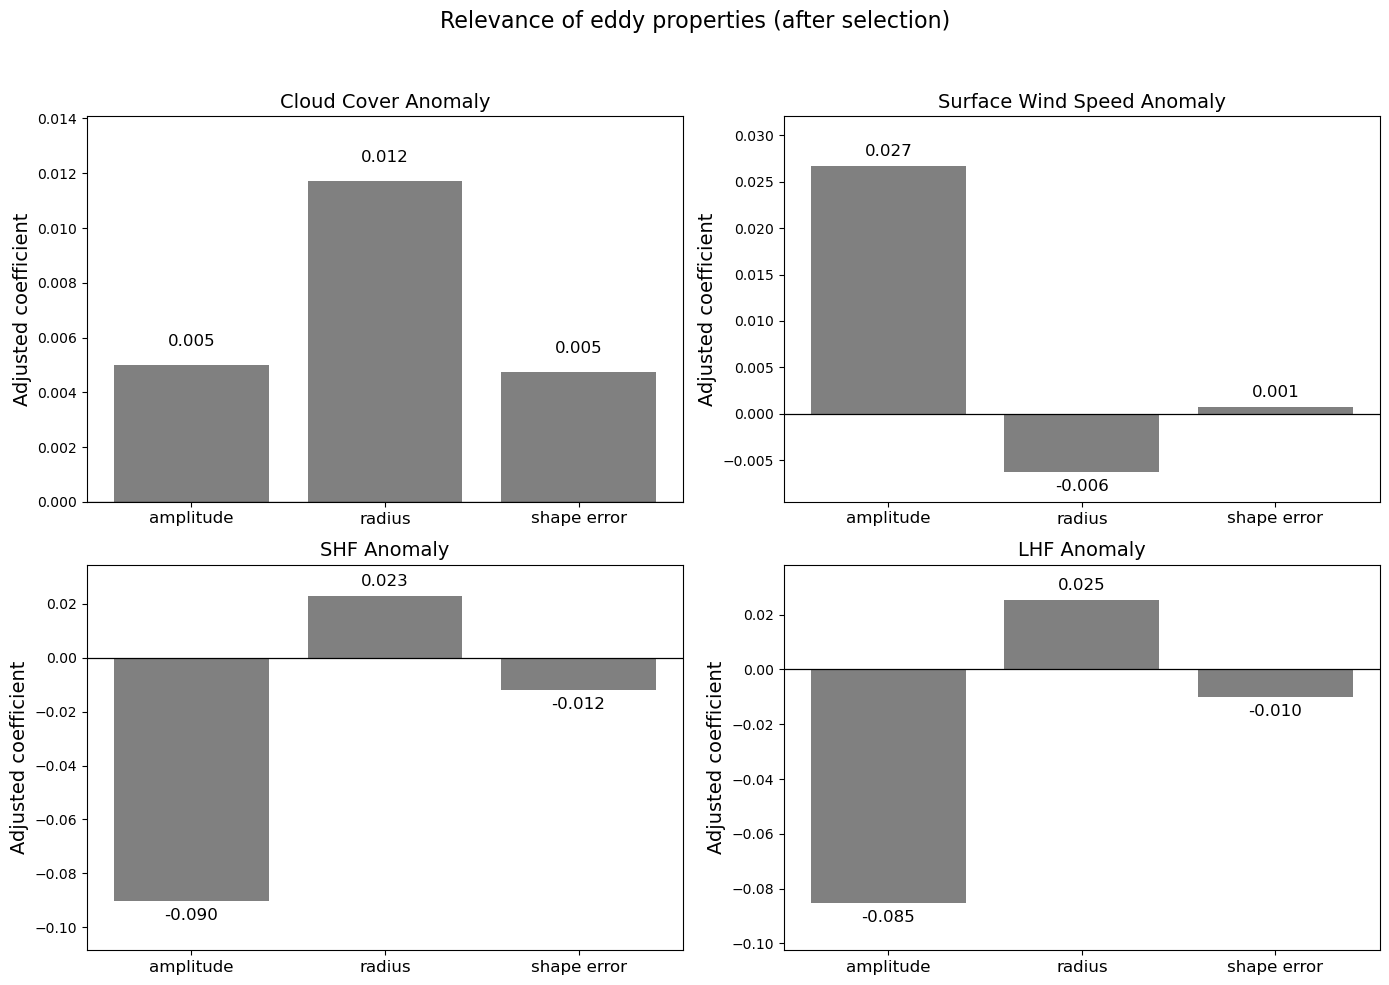

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14,10))

#Overall title
fig.suptitle("Relevance of eddy properties (after selection)", fontsize=16, y=0.98)

bar_color = "grey"

#cloud cover
coef_clt = pd.Series(adj_clt["beta"], index=X_std_clt.columns).drop("const", errors="ignore")

bars = axes[0,0].bar(coef_clt.index, coef_clt.values, color=bar_color)

# Fixed y-position for labels (a bit above zero)
y_text = coef_clt.max() * 0.05 if coef_clt.max() != 0 else 0.02

for i, v in enumerate(coef_clt.values):
    axes[0,0].text(i, max(v, 0) + y_text, f"{v:.3f}",
                    ha="center", va="bottom", fontsize=12)

axes[0,0].set_title("Cloud Cover Anomaly",  fontsize = 14)
axes[0,0].set_ylabel("Adjusted coefficient",  fontsize = 14)
axes[0,0].set_xticklabels(coef_clt.index, rotation=0, ha="center", fontsize = 12)
axes[0,0].axhline(0, color='black', linewidth=0.9)
axes[0,0].set_ylim(0, coef_clt.max() * 1.2)


#surface wind speed
coef_wind = pd.Series(adj_sfcwind["beta"], index=X_std_sfcwind.columns).drop("const", errors="ignore")

bars = axes[0,1].bar(coef_wind.index, coef_wind.values, color=bar_color)
axes[0,1].bar_label(bars, fmt="%.3f", padding=5, fontsize = 12)
axes[0,1].set_title("Surface Wind Speed Anomaly",  fontsize = 14)
axes[0,1].set_ylabel("Adjusted coefficient",  fontsize = 14)
axes[0,1].set_xticklabels(coef_wind.index, rotation=0, ha="center", fontsize = 12)
axes[0,1].axhline(0, color='black', linewidth=0.9)
axes[0,1].set_ylim(coef_wind.min() * 1.5, coef_wind.max() * 1.2)

#shf
coef_hfss = pd.Series(adj_hfss["beta"], index=X_std_hfss.columns).drop("const", errors="ignore")

bars = axes[1,0].bar(coef_hfss.index, coef_hfss.values, color=bar_color)
axes[1,0].bar_label(bars, fmt="%.3f", padding=5, fontsize = 12)
axes[1,0].set_title("SHF Anomaly",  fontsize = 14)
axes[1,0].set_ylabel("Adjusted coefficient",  fontsize = 14)
axes[1,0].set_xticklabels(coef_wind.index, rotation=0, ha="center", fontsize = 12)
axes[1,0].axhline(0, color='black', linewidth=0.9)
axes[1,0].set_ylim(coef_hfss.min() * 1.2, coef_hfss.max()*1.5)

#lhf
coef_hfls = pd.Series(adj_hfls["beta"], index=X_std_hfls.columns).drop("const", errors="ignore")

bars = axes[1,1].bar(coef_hfls.index, coef_hfls.values, color=bar_color)
axes[1,1].bar_label(bars, fmt="%.3f", padding=5, fontsize = 12)
axes[1,1].set_title("LHF Anomaly", fontsize = 14)
axes[1,1].set_ylabel("Adjusted coefficient",  fontsize = 14)
axes[1,1].set_xticklabels(coef_wind.index, rotation=0, ha="center", fontsize = 12)
axes[1,1].axhline(0, color='black', linewidth=0.9)
axes[1,1].set_ylim(coef_hfls.min() * 1.2, coef_hfls.max() * 1.5)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("eddy_prop_relevance_after_2.pdf")
plt.show()
